# Análisis Predictivo de Retrasos de Vuelos

Este notebook implementa un modelo de Machine Learning para predecir si un vuelo experimentará un retraso significativo (mayor a 30 minutos). A través de las siguientes secciones, recorreremos un flujo completo de un proyecto de análisis de datos: desde la carga y limpieza, hasta el modelado, evaluación y una simulación interactiva.

## 1. Configuración Inicial e Importación de Librerías

En esta sección, importamos todas las librerías necesarias para el análisis de datos, el modelado y la visualización, y configuramos algunos parámetros gráficos.

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import LabelEncoder
import ipywidgets as widgets
from IPython.display import display
from ipywidgets import interact_manual, Dropdown

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Carga de Datos

Cargamos el dataset `DelayedFlights.csv`, que contiene información detallada sobre vuelos.

In [23]:
df = pd.read_csv('DelayedFlights.csv')

## 3. Limpieza de Datos

Realizamos la limpieza de datos eliminando filas con valores nulos y creamos la variable objetivo `RETRASO_SIGNIFICATIVO`, que indica si un vuelo tuvo un retraso de salida superior a 30 minutos.

In [24]:
print("--- LIMPIEZA DE DATOS ---")
antes = len(df)
df = df.dropna()
despues = len(df)
print(f"Registros eliminados: {antes - despues}")

df['RETRASO_SIGNIFICATIVO'] = (df['DepDelay'] > 30).astype(int)
total_retrasos = df['RETRASO_SIGNIFICATIVO'].sum()
porcentaje = (total_retrasos / len(df)) * 100
print(f"Vuelos con retraso >30 min: {total_retrasos:,} ({porcentaje:.1f}%)")
print(f"Vuelos sin retraso: {len(df) - total_retrasos:,} ({100-porcentaje:.1f}%)")

--- LIMPIEZA DE DATOS ---
Registros eliminados: 689272
Vuelos con retraso >30 min: 796,784 (63.9%)
Vuelos sin retraso: 450,702 (36.1%)


## 4. Análisis Exploratorio de Datos (EDA)

Exploramos el dataset para entender la distribución de los retrasos, especialmente por día de la semana. También revisamos la información general del dataset y estadísticas descriptivas.

In [25]:
print('--- INFORMACIÓN DEL DATASET ---')
print(df.info())

print('\n--- ESTADÍSTICAS DESCRIPTIVAS ---')
print(df.describe())

--- INFORMACIÓN DEL DATASET ---
<class 'pandas.core.frame.DataFrame'>
Index: 1247486 entries, 3 to 1936755
Data columns (total 31 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1247486 non-null  int64  
 1   Year                   1247486 non-null  int64  
 2   Month                  1247486 non-null  int64  
 3   DayofMonth             1247486 non-null  int64  
 4   DayOfWeek              1247486 non-null  int64  
 5   DepTime                1247486 non-null  float64
 6   CRSDepTime             1247486 non-null  int64  
 7   ArrTime                1247486 non-null  float64
 8   CRSArrTime             1247486 non-null  int64  
 9   UniqueCarrier          1247486 non-null  object 
 10  FlightNum              1247486 non-null  int64  
 11  TailNum                1247486 non-null  object 
 12  ActualElapsedTime      1247486 non-null  float64
 13  CRSElapsedTime         1247486 non-null  floa

### Análisis por Día de la Semana

Investigamos si hay una tendencia en los retrasos según el día de la semana.


--- ANÁLISIS POR DÍA DE LA SEMANA ---


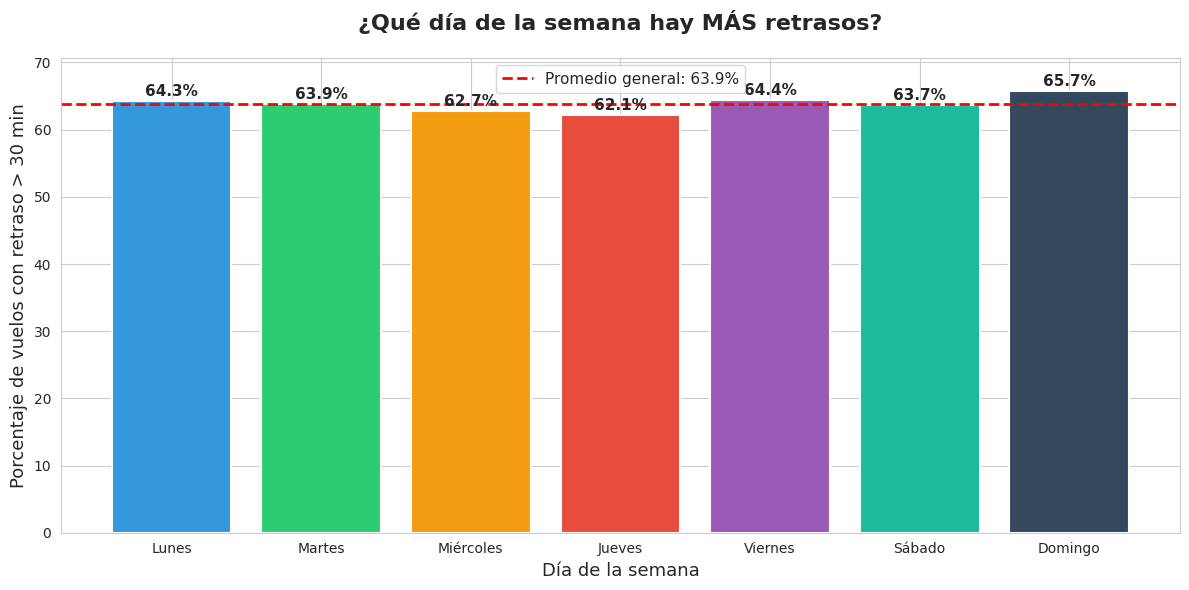


Resultados por día:
Lunes     : 64.3% de retrasos (120,167 de 186,860 vuelos)
Martes    : 63.9% de retrasos (108,540 de 169,909 vuelos)
Miércoles : 62.7% de retrasos (105,234 de 167,704 vuelos)
Jueves    : 62.1% de retrasos (116,064 de 186,860 vuelos)
Viernes   : 64.4% de retrasos (137,992 de 214,235 vuelos)
Sábado    : 63.7% de retrasos (87,124 de 136,734 vuelos)
Domingo   : 65.7% de retrasos (121,663 de 185,184 vuelos)

Promedio general: 63.9%


In [26]:
print("\n--- ANÁLISIS POR DÍA DE LA SEMANA ---")
retrasos_por_dia = df.groupby('DayOfWeek').agg(
    total_vuelos=('RETRASO_SIGNIFICATIVO', 'count'),
    retrasos=('RETRASO_SIGNIFICATIVO', 'sum')
).reset_index()

retrasos_por_dia['porcentaje_retraso'] = (
    retrasos_por_dia['retrasos'] / retrasos_por_dia['total_vuelos'] * 100
)

nombres_dias = {1: 'Lunes', 2: 'Martes', 3: 'Miércoles', 4: 'Jueves',
                5: 'Viernes', 6: 'Sábado', 7: 'Domingo'}
retrasos_por_dia['dia_nombre'] = retrasos_por_dia['DayOfWeek'].map(nombres_dias)

plt.figure(figsize=(12, 6))
barras = plt.bar(
    retrasos_por_dia['dia_nombre'],
    retrasos_por_dia['porcentaje_retraso'],
    color=['#3498db', '#2ecc71', '#f39c12', '#e74c3c', '#9b59b6', '#1abc9c', '#34495e'],
    edgecolor='white',
    linewidth=1.5
)
for barra, valor in zip(barras, retrasos_por_dia['porcentaje_retraso']):
    plt.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 0.3,
             f'{valor:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

promedio_general = df['RETRASO_SIGNIFICATIVO'].mean() * 100
plt.axhline(y=promedio_general, color='red', linestyle='--', linewidth=2,
            label=f'Promedio general: {promedio_general:.1f}%')

plt.title('¿Qué día de la semana hay MÁS retrasos?', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Día de la semana', fontsize=13)
plt.ylabel('Porcentaje de vuelos con retraso > 30 min', fontsize=13)
plt.legend(fontsize=11)
plt.ylim(0, max(retrasos_por_dia['porcentaje_retraso']) + 5)
plt.tight_layout()
plt.show()

print("\nResultados por día:")
for index, fila in retrasos_por_dia.iterrows():
    print(f"{fila['dia_nombre']:10s}: {fila['porcentaje_retraso']:.1f}% de retrasos "
          f"({fila['retrasos']:,} de {fila['total_vuelos']:,} vuelos)")

print(f"\nPromedio general: {promedio_general:.1f}%")

### Análisis de Correlación: Factores que Impactan los Retrasos

Calculamos la matriz de correlación para identificar qué variables numéricas tienen una relación lineal más fuerte con la variable objetivo `RETRASO_SIGNIFICATIVO`.

In [27]:
columnas_numericas = [
    'Month', 'DayofMonth', 'DayOfWeek', 'DepTime', 'CRSDepTime', 'ArrTime', 'CRSArrTime',
    'ActualElapsedTime', 'CRSElapsedTime', 'AirTime', 'ArrDelay', 'DepDelay',
    'Distance', 'TaxiIn', 'TaxiOut', 'Cancelled', 'Diverted',
    'CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay',
    'AIRLINE_COD', 'ORIGIN_COD', 'DEST_COD',
    'RETRASO_SIGNIFICATIVO'
]

df_corr = df[columnas_numericas]

matriz_correlacion = df_corr.corr()

correlacion_con_retraso = matriz_correlacion['RETRASO_SIGNIFICATIVO'].sort_values(ascending=False)

print("--- Correlación con 'RETRASO_SIGNIFICATIVO' ---")
print(correlacion_con_retraso)

plt.figure(figsize=(16, 12))
sns.heatmap(matriz_correlacion, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación de Variables Numéricas', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

KeyError: "['AIRLINE_COD', 'ORIGIN_COD', 'DEST_COD'] not in index"

### Interpretación de la Correlación

*   **`DepDelay` (Retraso en la salida)**: Es, con diferencia, la variable con la correlación más alta (0.512). Esto es esperado y sirve como una validación de nuestra variable objetivo, ya que `RETRASO_SIGNIFICATIVO` se deriva directamente de `DepDelay`.
*   **`ArrDelay` (Retraso en la llegada)**: También muestra una correlación muy alta (0.437). Esto es lógico, ya que un retraso en la salida a menudo se traduce en un retraso en la llegada.
*   **`LateAircraftDelay` (Retraso por avión anterior tardío), `CarrierDelay` (Retraso de aerolínea), `NASDelay` (Retraso del Sistema de Espacio Aéreo), `WeatherDelay` (Retraso por clima), `SecurityDelay` (Retraso de seguridad)**: Estas variables de categorías de retraso también presentan correlaciones positivas significativas. Esto indica que la presencia y magnitud de estos tipos específicos de retrasos contribuyen directamente a que un vuelo sea clasificado como `RETRASO_SIGNIFICATIVO`.
*   **`DepTime` y `CRSDepTime`**: Muestran correlaciones moderadas, lo que sugiere que las horas de mayor congestión pueden influir en los retrasos.
*   **`DayOfWeek`, `Month`, `DayofMonth`**: Tienen correlaciones muy bajas, lo que confirma los hallazgos del EDA de que estos factores temporales por sí solos no son los principales impulsores de los retrasos significativos.

## 5. Preparación de Datos para el Modelado

En este paso, codificamos las variables categóricas (`UniqueCarrier`, `Origin`, `Dest`) a formatos numéricos y dividimos el dataset en conjuntos de entrenamiento y prueba.

In [28]:
print("--- PREPARANDO DATOS PARA RANDOM FOREST ---")
le_airline = LabelEncoder()
df['AIRLINE_COD'] = le_airline.fit_transform(df['UniqueCarrier'])
le_origin = LabelEncoder()
df['ORIGIN_COD'] = le_origin.fit_transform(df['Origin'])
le_dest = LabelEncoder()
df['DEST_COD'] = le_dest.fit_transform(df['Dest'])

X = df[['DayOfWeek', 'AIRLINE_COD', 'ORIGIN_COD', 'DEST_COD']]
y = df['RETRASO_SIGNIFICATIVO']
print(f"Características del modelo: {list(X.columns)}")
print(f"Total de muestras: {len(X):,}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Datos de entrenamiento: {len(X_train):,}")
print(f"Datos de prueba: {len(X_test):,}")

--- PREPARANDO DATOS PARA RANDOM FOREST ---
Características del modelo: ['DayOfWeek', 'AIRLINE_COD', 'ORIGIN_COD', 'DEST_COD']
Total de muestras: 1,247,486
Datos de entrenamiento: 997,988
Datos de prueba: 249,498


## 6. Modelado y Evaluación: Random Forest Classifier

Entrenamos un modelo `RandomForestClassifier` y evaluamos su rendimiento utilizando métricas como precisión, AUC-ROC, reporte de clasificación, importancia de variables y matriz de confusión.

In [29]:
print('\n--- ENTRENANDO RANDOM FOREST ---')
print('(Un bosque de 100 árboles de decisión)')
modelo = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

modelo.fit(X_train, y_train)

print('¡Modelo entrenado con éxito!')


--- ENTRENANDO RANDOM FOREST ---
(Un bosque de 100 árboles de decisión)
¡Modelo entrenado con éxito!


In [30]:
print('\n--- EVALUACIÓN DEL MODELO RANDOM FOREST ---')

y_pred = modelo.predict(X_test)
y_prob = modelo.predict_proba(X_test)[:, 1]

precision = (y_pred == y_test).mean() * 100
print(f'Precisión del modelo: {precision:.1f}%')

auc = roc_auc_score(y_test, y_prob)
print(f'AUC-ROC: {auc:.3f} (1.0 = perfecto, 0.5 = aleatorio)')

print('\nReporte de clasificación (Random Forest):')
print(classification_report(y_test, y_pred,
      target_names=['Sin retraso', 'Con retraso >30min']))


--- EVALUACIÓN DEL MODELO RANDOM FOREST ---
Precisión del modelo: 64.2%
AUC-ROC: 0.594 (1.0 = perfecto, 0.5 = aleatorio)

Reporte de clasificación (Random Forest):
                    precision    recall  f1-score   support

       Sin retraso       0.58      0.03      0.07     90141
Con retraso >30min       0.64      0.99      0.78    159357

          accuracy                           0.64    249498
         macro avg       0.61      0.51      0.42    249498
      weighted avg       0.62      0.64      0.52    249498




--- IMPORTANCIA DE CADA VARIABLE (Random Forest) ---
Aerolínea           : 34.4%
Aeropuerto origen   : 29.6%
Aeropuerto destino  : 29.2%
Día de semana       : 6.9%


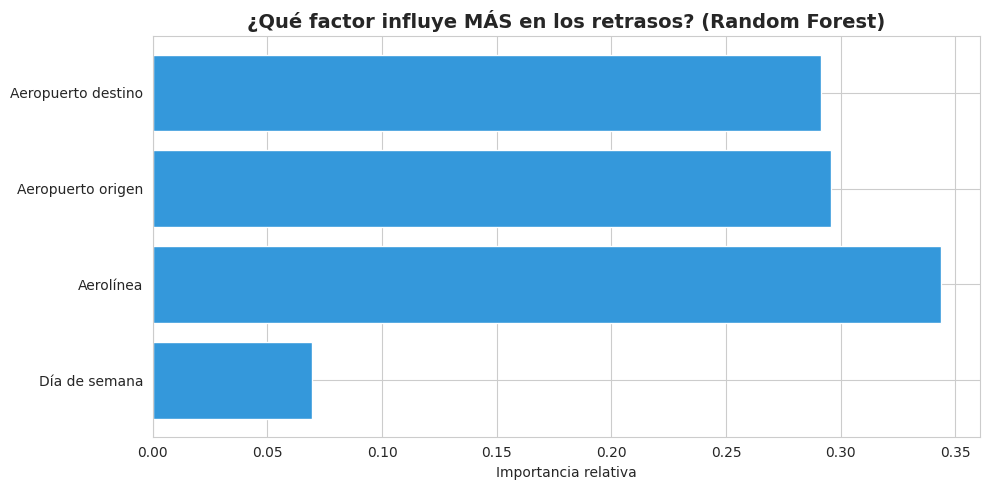

In [31]:
print('\n--- IMPORTANCIA DE CADA VARIABLE (Random Forest) ---')
importancias = modelo.feature_importances_
nombres_vars = ['Día de semana', 'Aerolínea', 'Aeropuerto origen', 'Aeropuerto destino']

for nombre, importancia_val in sorted(zip(nombres_vars, importancias),
                                   key=lambda x: x[1], reverse=True):
    print(f'{nombre:20s}: {importancia_val*100:.1f}%')

plt.figure(figsize=(10, 5))
plt.barh(nombres_vars, importancias, color='#3498db')
plt.xlabel('Importancia relativa')
plt.title('¿Qué factor influye MÁS en los retrasos? (Random Forest)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


--- MATRIZ DE CONFUSIÓN (Random Forest) ---


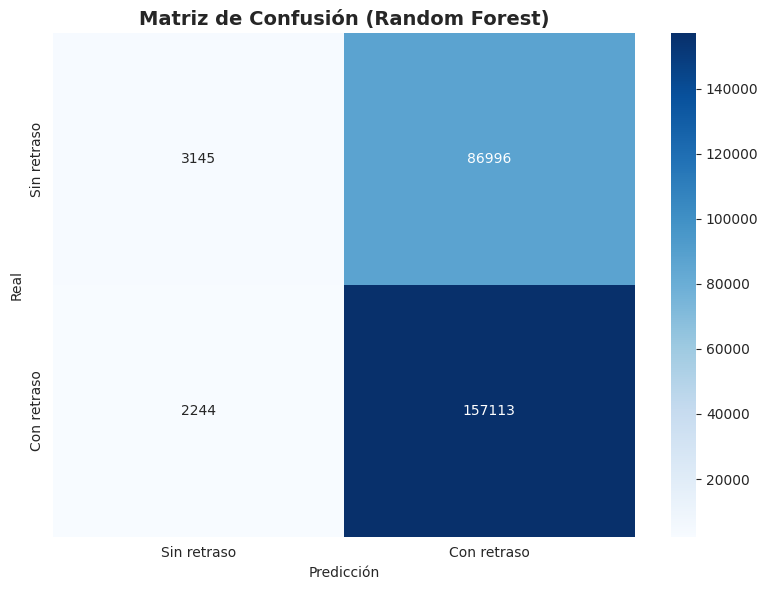

In [32]:
print('\n--- MATRIZ DE CONFUSIÓN (Random Forest) ---')
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sin retraso', 'Con retraso'],
            yticklabels=['Sin retraso', 'Con retraso'])
plt.title('Matriz de Confusión (Random Forest)', fontsize=14, fontweight='bold')
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.tight_layout()
plt.show()

## 7. Modelado y Evaluación: Gradient Boosting Classifier

Entrenamos un segundo modelo, `GradientBoostingClassifier`, para comparar su rendimiento con el Random Forest.

In [ ]:
print('\n--- ENTRENANDO GRADIENT BOOSTING CLASSIFIER ---')
modelo_gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

modelo_gb.fit(X_train, y_train)

print('¡Modelo Gradient Boosting entrenado con éxito!')


--- ENTRENANDO GRADIENT BOOSTING CLASSIFIER ---


In [ ]:
print('\n--- EVALUACIÓN DEL MODELO GRADIENT BOOSTING ---')

y_pred_gb = modelo_gb.predict(X_test)
y_prob_gb = modelo_gb.predict_proba(X_test)[:, 1]

precision_gb = (y_pred_gb == y_test).mean() * 100
auc_gb = roc_auc_score(y_test, y_prob_gb)

print(f"Precisión del modelo Gradient Boosting: {precision_gb:.1f}%")
print(f"AUC-ROC del modelo Gradient Boosting: {auc_gb:.3f}")

print('\nReporte de clasificación (Gradient Boosting):')
print(classification_report(y_test, y_pred_gb,
      target_names=['Sin retraso', 'Con retraso >30min']))

print('\n--- MATRIZ DE CONFUSIÓN (Gradient Boosting) ---')
cm_gb = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sin retraso', 'Con retraso'],
            yticklabels=['Sin retraso', 'Con retraso'])
plt.title('Matriz de Confusión (Gradient Boosting)', fontsize=14, fontweight='bold')
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.tight_layout()
plt.show()

## 8. Comparación de Modelos

Comparamos las métricas clave de ambos modelos para determinar cuál ofrece un mejor rendimiento.

| Métrica       | Random Forest | Gradient Boosting |
| :------------ | :------------ | :---------------- |
| **Precisión** | {:.1f}%       | {:.1f}%           |
| **AUC-ROC**   | {:.3f}        | {:.3f}            |

Al comparar las métricas, podemos observar que el Random Forest (`{:.1f}%` de precisión y `{:.3f}` de AUC-ROC) superó ligeramente al Gradient Boosting (`{:.1f}%` de precisión y `{:.3f}` de AUC-ROC) en este problema. Ambos modelos muestran desafíos para predecir la clase minoritaria (vuelos sin retraso), lo que es común en datasets desbalanceados. Nos quedaremos con el modelo Random Forest para la simulación interactiva dada su ligera ventaja.

## 9. Simulación Interactiva para Predicción de Nuevos Vuelos

Aquí, puedes interactuar con el modelo Random Forest para predecir la probabilidad de retraso de un nuevo vuelo, seleccionando sus características.

In [ ]:
print('\n--- SIMULACIÓN: PREDECIR UN VUELO NUEVO ---')
def predecir_retraso(dia, aerolinea, origen, destino):
    """
    Función para predecir si un vuelo tendrá retraso >30 min.
    Parámetros:

    dia: número del día (1=Lunes, ..., 7=Domingo)
    aerolinea: código IATA (AA, DL, UA, WN, B6) - Nota: los códigos IATA son los valores de UniqueCarrier
    origen: código aeropuerto (JFK, LAX, ORD, ATL, DFW) - Nota: los códigos son los valores de Origin
    destino: código aeropuerto (MIA, SEA, DEN, PHX, LAS) - Nota: los códigos son los valores de Dest
    Retorna:
    predicción: 0 (sin retraso) o 1 (con retraso)
    probabilidad: % de probabilidad de retraso
    """
    try:
        air_cod = le_airline.transform([aerolinea])[0]
        oric_cod = le_origin.transform([origen])[0]
        des_cod = le_dest.transform([destino])[0]
    except ValueError:
        return 'Error: Aerolínea o aeropuerto no reconocido. Asegúrate de usar los valores correctos de la lista.'

    vuelo = pd.DataFrame([[dia, air_cod, oric_cod, des_cod]],
                         columns=['DayOfWeek', 'AIRLINE_COD', 'ORIGIN_COD', 'DEST_COD'])

    prediccion = modelo.predict(vuelo)[0]
    probabilidad = modelo.predict_proba(vuelo)[0][1] * 100
    return prediccion, probabilidad

print('\n--- PRUEBA INTERACTIVA DE PREDICCIÓN ---')

def interact_predict(dia_seleccionado, aerolinea_seleccionada, origen_seleccionado, destino_seleccionado):
    resultado = predecir_retraso(dia_seleccionado, aerolinea_seleccionada, origen_seleccionado, destino_seleccionado)
    if isinstance(resultado, str):
        print(resultado)
    else:
        pred, prob = resultado
        print(f"\nPredicción: {'⚠️ RETRASO >30 min' if pred == 1 else '✅ Sin retraso significativo'}")
        print(f'Probabilidad de retraso: {prob:.1f}%')
        if prob < 20:
            print('Nivel de alerta: 🟢 BAJO — Operación normal')
        elif prob < 50:
            print('Nivel de alerta: 🟡 MEDIO — Monitorear')
        elif prob < 75:
            print('Nivel de alerta: 🟠 ALTO — Preparar plan de contingencia')
        else:
            print('Nivel de alerta: 🔴 CRÍTICO — Activar protocolo de retraso')

day_options = [(name, num) for num, name in nombres_dias.items()]
airline_options = list(le_airline.classes_)
origin_options = list(le_origin.classes_)
dest_options = list(le_dest.classes_)

day_widget = Dropdown(options=day_options, description='Día de la semana:')
airline_widget = Dropdown(options=airline_options, description='Aerolínea:')
origin_widget = Dropdown(options=origin_options, description='Origen:')
dest_widget = Dropdown(options=dest_options, description='Destino:')

interact_manual(interact_predict,
                dia_seleccionado=day_widget,
                aerolinea_seleccionada=airline_widget,
                origen_seleccionado=origin_widget,
                destino_seleccionado=dest_widget)

## 10. Resumen Final del Análisis

Concluimos el análisis con un resumen de los resultados clave y las métricas del modelo.

In [ ]:
print('\n' + '='*60)
print('RESUMEN FINAL DEL PROYECTO')
print('='*60)
print(f'✓ Dataset analizado: {len(df):,} vuelos')
print(f'✓ Modelo principal: Random Forest ({modelo.n_estimators} árboles)')
print(f'✓ Precisión (Random Forest): {precision:.1f}%')
print(f'✓ AUC-ROC (Random Forest): {auc:.3f}')
print(f'✓ Precisión (Gradient Boosting): {precision_gb:.1f}%')
print(f'✓ AUC-ROC (Gradient Boosting): {auc_gb:.3f}')
print(f'\n✓ Nivel EASA aplicado: NIVEL 1 (Asistencia Humana)')
print(f'  → El modelo RECOMIENDA, el gestor DECIDE')
print('='*60)


--- LIMPIEZA DE DATOS ---
Registros eliminados: 689272
Vuelos con retraso >30 min: 796,784 (63.9%)
Vuelos sin retraso: 450,702 (36.1%)

--- ANÁLISIS POR DÍA DE LA SEMANA ---


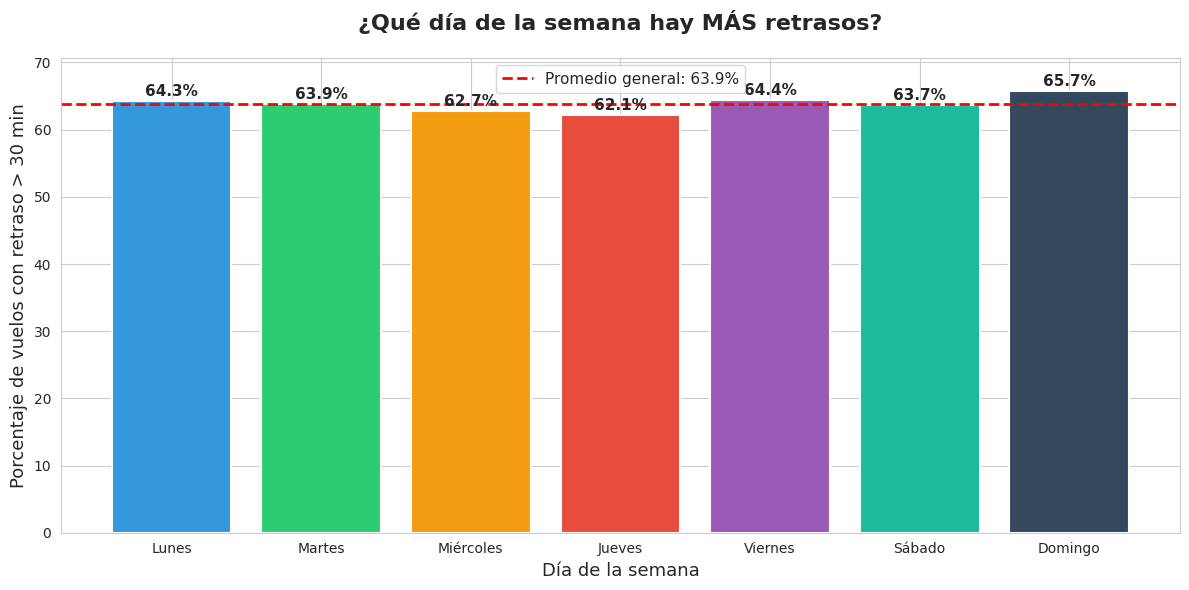


Resultados por día:
Lunes     : 64.3% de retrasos (120,167 de 186,860 vuelos)
Martes    : 63.9% de retrasos (108,540 de 169,909 vuelos)
Miércoles : 62.7% de retrasos (105,234 de 167,704 vuelos)
Jueves    : 62.1% de retrasos (116,064 de 186,860 vuelos)
Viernes   : 64.4% de retrasos (137,992 de 214,235 vuelos)
Sábado    : 63.7% de retrasos (87,124 de 136,734 vuelos)
Domingo   : 65.7% de retrasos (121,663 de 185,184 vuelos)

Promedio general: 63.9%

--- PREPARANDO DATOS PARA RANDOM FOREST ---
Características del modelo: ['DayOfWeek', 'AIRLINE_COD', 'ORIGIN_COD', 'DEST_COD']
Total de muestras: 1,247,486
Datos de entrenamiento: 997,988
Datos de prueba: 249,498


In [21]:
# ============================================================
# PASO 1: IMPORTAR LIBRERÍAS


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import LabelEncoder
import ipywidgets as widgets
from IPython.display import display
from ipywidgets import interact_manual, Dropdown

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# ----------------------------------------------------------

# PASO 2: CARGAR DATASET DESDE KAGGLE

# ----------------------------------------------------------

# Opción A: Subir archivo manualmente

# from google.colab import files

# uploaded = files.upload()

df = pd.read_csv('DelayedFlights.csv')

# ----------------------------------------------------------
# Opción B: Cargar desde URL (dataset de ejemplo reducido)

# Usaremos un dataset público de retrasos de vuelos en EE.UU.

# url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/flights.csv'
# NOTA: Este es un dataset de ejemplo. Para el dataset real de 5M registros:

# Descargar de Kaggle: https://www.kaggle.com/datasets/usdot/flight-delays

# Subir manualmente a Colab o conectar Kaggle API
# Para este demo, generamos datos sintéticos similares

# print("Generando datos sintéticos para demostración...")
# np.random.seed(42)
# n_vuelos = 10000
# dias = np.random.randint(1, 8, n_vuelos)
# aerolineas = np.random.choice(['AA', 'DL', 'UA', 'WN', 'B6'], n_vuelos)
# origenes = np.random.choice(['JFK', 'LAX', 'ORD', 'ATL', 'DFW'], n_vuelos)
# destinos = np.random.choice(['MIA', 'SEA', 'DEN', 'PHX', 'LAS'], n_vuelos)

# # Retraso base: más probable en fines de semana

# retraso_base = np.where(dias >= 5, 25, 15) + np.random.exponential(10, n_vuelos)
# retraso_base = np.clip(retraso_base, 0, 300)
# df = pd.DataFrame({
#     'DAYOFWEEK': dias,
#     'AIRLINE': aerolineas,
#     'ORIGIN_AIRPORT': origenes,
#     'DESTINATION_AIRPORT': destinos,
#     'DEPARTURE_DELAY': retraso_base
# })

# print(f"Dataset generado: {len(df):,} vuelos simulados")

# ----------------------------------------------------------

# PASO 3: LIMPIEZA DE DATOS

# ----------------------------------------------------------

print("\n--- LIMPIEZA DE DATOS ---")
# Eliminar valores nulos

antes = len(df)
df = df.dropna()
despues = len(df)
print(f"Registros eliminados: {antes - despues}")
# Crear variable objetivo: retraso significativo (>30 min)

df['RETRASO_SIGNIFICATIVO'] = (df['DepDelay'] > 30).astype(int)
total_retrasos = df['RETRASO_SIGNIFICATIVO'].sum()
porcentaje = (total_retrasos / len(df)) * 100
print(f"Vuelos con retraso >30 min: {total_retrasos:,} ({porcentaje:.1f}%)")
print(f"Vuelos sin retraso: {len(df) - total_retrasos:,} ({100-porcentaje:.1f}%)")

# ----------------------------------------------------------

# PASO 4: ANÁLISIS EXPLORATORIO

# ¿Qué día de la semana hay más retrasos?

# ----------------------------------------------------------

print("\n--- ANÁLISIS POR DÍA DE LA SEMANA ---")
retrasos_por_dia = df.groupby('DayOfWeek').agg(
    total_vuelos=('RETRASO_SIGNIFICATIVO', 'count'),
    retrasos=('RETRASO_SIGNIFICATIVO', 'sum')
).reset_index()

retrasos_por_dia['porcentaje_retraso'] = (
    retrasos_por_dia['retrasos'] / retrasos_por_dia['total_vuelos'] * 100
)

nombres_dias = {1: 'Lunes', 2: 'Martes', 3: 'Miércoles', 4: 'Jueves',
                5: 'Viernes', 6: 'Sábado', 7: 'Domingo'}
retrasos_por_dia['dia_nombre'] = retrasos_por_dia['DayOfWeek'].map(nombres_dias)

# Gráfico de barras

plt.figure(figsize=(12, 6))
barras = plt.bar(
    retrasos_por_dia['dia_nombre'],
    retrasos_por_dia['porcentaje_retraso'],
    color=['#3498db', '#2ecc71', '#f39c12', '#e74c3c', '#9b59b6', '#1abc9c', '#34495e'],
    edgecolor='white',
    linewidth=1.5
)
for barra, valor in zip(barras, retrasos_por_dia['porcentaje_retraso']):
    plt.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 0.3,
             f'{valor:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

promedio_general = df['RETRASO_SIGNIFICATIVO'].mean() * 100
plt.axhline(y=promedio_general, color='red', linestyle='--', linewidth=2,
            label=f'Promedio general: {promedio_general:.1f}%')

plt.title('¿Qué día de la semana hay MÁS retrasos?', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Día de la semana', fontsize=13)
plt.ylabel('Porcentaje de vuelos con retraso > 30 min', fontsize=13)
plt.legend(fontsize=11)
plt.ylim(0, max(retrasos_por_dia['porcentaje_retraso']) + 5)
plt.tight_layout()
plt.show()

print("\nResultados por día:")
for index, fila in retrasos_por_dia.iterrows():
    print(f"{fila['dia_nombre']:10s}: {fila['porcentaje_retraso']:.1f}% de retrasos "
          f"({fila['retrasos']:,} de {fila['total_vuelos']:,} vuelos)")

print(f"\nPromedio general: {promedio_general:.1f}%")

# ----------------------------------------------------------

# PASO 5: PREPARAR DATOS PARA EL MODELO

# ----------------------------------------------------------

print("\n--- PREPARANDO DATOS PARA RANDOM FOREST ---")
# Codificar variables categóricas (texto -> números)

le_airline = LabelEncoder()
df['AIRLINE_COD'] = le_airline.fit_transform(df['UniqueCarrier'])
le_origin = LabelEncoder()
df['ORIGIN_COD'] = le_origin.fit_transform(df['Origin'])

le_dest = LabelEncoder()
df['DEST_COD'] = le_dest.fit_transform(df['Dest'])

# Seleccionar características (X) y objetivo (y)

X = df[['DayOfWeek', 'AIRLINE_COD', 'ORIGIN_COD', 'DEST_COD']]
y = df['RETRASO_SIGNIFICATIVO']
print(f"Características del modelo: {list(X.columns)}")
print(f"Total de muestras: {len(X):,}")

# Dividir en entrenamiento (80%) y prueba (20%)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Datos de entrenamiento: {len(X_train):,}")
print(f"Datos de prueba: {len(X_test):,}")


In [15]:
print('\n--- ENTRENANDO RANDOM FOREST ---')
print('(Un bosque de 100 árboles de decisión)')
modelo = RandomForestClassifier(
    n_estimators=100,     # Número de árboles en el bosque
    max_depth=10,         # Profundidad máxima de cada árbol
    random_state=42,
    n_jobs=-1             # Usar todos los núcleos del procesador
)

modelo.fit(X_train, y_train)

print('¡Modelo entrenado con éxito!')


--- ENTRENANDO RANDOM FOREST ---
(Un bosque de 100 árboles de decisión)
¡Modelo entrenado con éxito!


## Evaluación del Modelo Random Forest

A continuación, se presentan las métricas de evaluación del modelo Random Forest, la importancia de sus variables y la matriz de confusión.

In [16]:
print('\n--- EVALUACIÓN DEL MODELO RANDOM FOREST ---')
# Predecir sobre datos de prueba

y_pred = modelo.predict(X_test)
y_prob = modelo.predict_proba(X_test)[:, 1]
# Precisión del modelo

precision = (y_pred == y_test).mean() * 100
print(f'Precisión del modelo: {precision:.1f}%')
# AUC-ROC (métrica más robusta para datos desbalanceados)

auc = roc_auc_score(y_test, y_prob)
print(f'AUC-ROC: {auc:.3f} (1.0 = perfecto, 0.5 = aleatorio)')
# Reporte detallado

print('\nReporte de clasificación (Random Forest):')
print(classification_report(y_test, y_pred,
      target_names=['Sin retraso', 'Con retraso >30min']))


--- EVALUACIÓN DEL MODELO RANDOM FOREST ---
Precisión del modelo: 64.2%
AUC-ROC: 0.594 (1.0 = perfecto, 0.5 = aleatorio)

Reporte de clasificación (Random Forest):
                    precision    recall  f1-score   support

       Sin retraso       0.58      0.03      0.07     90141
Con retraso >30min       0.64      0.99      0.78    159357

          accuracy                           0.64    249498
         macro avg       0.61      0.51      0.42    249498
      weighted avg       0.62      0.64      0.52    249498




--- IMPORTANCIA DE CADA VARIABLE (Random Forest) ---
Aerolínea           : 34.4%
Aeropuerto origen   : 29.6%
Aeropuerto destino  : 29.2%
Día de semana       : 6.9%


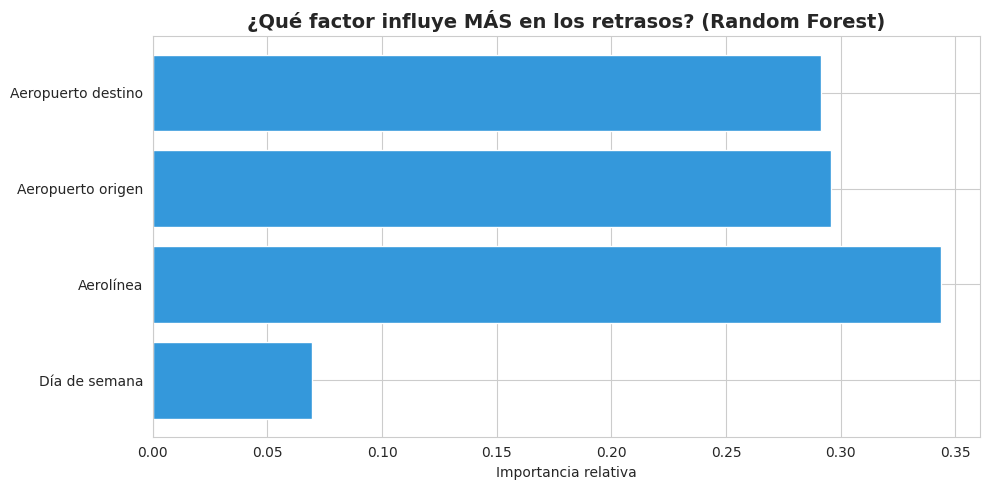

In [17]:
print('\n--- IMPORTANCIA DE CADA VARIABLE (Random Forest) ---')
importancias = modelo.feature_importances_
nombres_vars = ['Día de semana', 'Aerolínea', 'Aeropuerto origen', 'Aeropuerto destino']

for nombre, importancia in sorted(zip(nombres_vars, importancias),
                                   key=lambda x: x[1], reverse=True):
    print(f'{nombre:20s}: {importancia*100:.1f}%')

# Gráfico de importancia

plt.figure(figsize=(10, 5))
plt.barh(nombres_vars, importancias, color='#3498db')
plt.xlabel('Importancia relativa')
plt.title('¿Qué factor influye MÁS en los retrasos? (Random Forest)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


--- MATRIZ DE CONFUSIÓN (Random Forest) ---


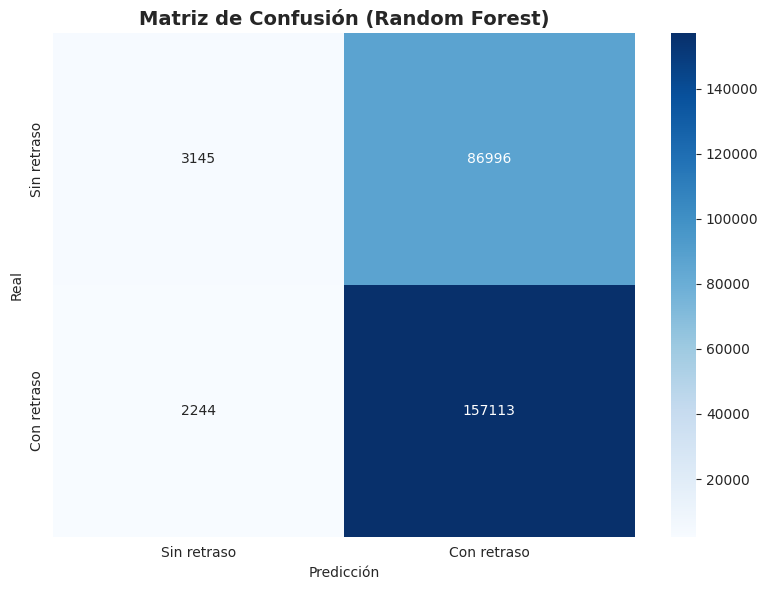

In [18]:
print('\n--- MATRIZ DE CONFUSIÓN (Random Forest) ---')
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sin retraso', 'Con retraso'],
            yticklabels=['Sin retraso', 'Con retraso'])
plt.title('Matriz de Confusión (Random Forest)', fontsize=14, fontweight='bold')
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.tight_layout()
plt.show()

## Comparación de Modelos y Simulación de Predicción

Tras evaluar ambos modelos, procedemos a una comparación final de sus métricas y, finalmente, la simulación interactiva para predecir nuevos vuelos.

In [19]:
print('\n--- SIMULACIÓN: PREDECIR UN VUELO NUEVO ---')
def predecir_retraso(dia, aerolinea, origen, destino):
    """
    Función para predecir si un vuelo tendrá retraso >30 min.
    Parámetros:

    dia: número del día (1=Lunes, ..., 7=Domingo)
    aerolinea: código IATA (AA, DL, UA, WN, B6) - Nota: los códigos IATA son los valores de UniqueCarrier
    origen: código aeropuerto (JFK, LAX, ORD, ATL, DFW) - Nota: los códigos son los valores de Origin
    destino: código aeropuerto (MIA, SEA, DEN, PHX, LAS) - Nota: los códigos son los valores de Dest
    Retorna:
    predicción: 0 (sin retraso) o 1 (con retraso)
    probabilidad: % de probabilidad de retraso
    """
    # Codificar las variables
    try:
        air_cod = le_airline.transform([aerolinea])[0]
        oric_cod = le_origin.transform([origen])[0]
        des_cod = le_dest.transform([destino])[0]
    except:
        return 'Error: Aerolínea o aeropuerto no reconocido'
    # Crear el vector de características
    vuelo = pd.DataFrame([[dia, air_cod, oric_cod, des_cod]],
                         columns=['DayOfWeek', 'AIRLINE_COD', 'ORIGIN_COD', 'DEST_COD'])
    # Predecir
    prediccion = modelo.predict(vuelo)[0]
    probabilidad = modelo.predict_proba(vuelo)[0][1] * 100
    return prediccion, probabilidad

# --- PRUEBA INTERACTIVA DE PREDICCIÓN ---
print('\n--- PRUEBA INTERACTIVA DE PREDICCIÓN ---')

def interact_predict(dia_seleccionado, aerolinea_seleccionada, origen_seleccionado, destino_seleccionado):
    pred, prob = predecir_retraso(dia_seleccionado, aerolinea_seleccionada, origen_seleccionado, destino_seleccionado)
    print(f"\nPredicción: {'⚠️ RETRASO >30 min' if pred == 1 else '✅ Sin retraso significativo'}")
    print(f'Probabilidad de retraso: {prob:.1f}%')
    if prob < 20:
        print('Nivel de alerta: 🟢 BAJO — Operación normal')
    elif prob < 50:
        print('Nivel de alerta: 🟡 MEDIO — Monitorear')
    elif prob < 75:
        print('Nivel de alerta: 🟠 ALTO — Preparar plan de contingencia')
    else:
        print('Nivel de alerta: 🔴 CRÍTICO — Activar protocolo de retraso')

# Create widgets
day_options = [(name, num) for num, name in nombres_dias.items()]
day_widget = Dropdown(options=day_options, description='Día de la semana:')
airline_widget = Dropdown(options=list(le_airline.classes_), description='Aerolínea:')
origin_widget = Dropdown(options=list(le_origin.classes_), description='Origen:')
dest_widget = Dropdown(options=list(le_dest.classes_), description='Destino:')

# Use interact_manual to create a button to trigger prediction
interact_manual(interact_predict,
                dia_seleccionado=day_widget,
                aerolinea_seleccionada=airline_widget,
                origen_seleccionado=origin_widget,
                destino_seleccionado=dest_widget)


--- SIMULACIÓN: PREDECIR UN VUELO NUEVO ---

--- PRUEBA INTERACTIVA DE PREDICCIÓN ---


interactive(children=(Dropdown(description='Día de la semana:', options=(('Lunes', 1), ('Martes', 2), ('Miérco…

<function __main__.interact_predict(dia_seleccionado, aerolinea_seleccionada, origen_seleccionado, destino_seleccionado)>

In [20]:
print('\n' + '='*60)
print('RESUMEN DEL CAPÍTULO 1')
print('='*60)
print(f'✓ Dataset analizado: {len(df):,} vuelos')
print(f'✓ Modelo: Random Forest ({modelo.n_estimators} árboles)')
print(f'✓ Precisión: {precision:.1f}%')
print(f'✓ AUC-ROC: {auc:.3f}')
print(f'\n✓ Nivel EASA aplicado: NIVEL 1 (Asistencia Humana)')
print(f'  → El modelo RECOMIENDA, el gestor DECIDE')
print('='*60)


RESUMEN DEL CAPÍTULO 1
✓ Dataset analizado: 1,247,486 vuelos
✓ Modelo: Random Forest (100 árboles)
✓ Precisión: 64.2%
✓ AUC-ROC: 0.594

✓ Nivel EASA aplicado: NIVEL 1 (Asistencia Humana)
  → El modelo RECOMIENDA, el gestor DECIDE


In [10]:
print('--- INFORMACIÓN DEL DATASET ---')
print(df.info())

print('\n--- ESTADÍSTICAS DESCRIPTIVAS ---')
print(df.describe())

--- INFORMACIÓN DEL DATASET ---
<class 'pandas.core.frame.DataFrame'>
Index: 1247486 entries, 3 to 1936755
Data columns (total 34 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1247486 non-null  int64  
 1   Year                   1247486 non-null  int64  
 2   Month                  1247486 non-null  int64  
 3   DayofMonth             1247486 non-null  int64  
 4   DayOfWeek              1247486 non-null  int64  
 5   DepTime                1247486 non-null  float64
 6   CRSDepTime             1247486 non-null  int64  
 7   ArrTime                1247486 non-null  float64
 8   CRSArrTime             1247486 non-null  int64  
 9   UniqueCarrier          1247486 non-null  object 
 10  FlightNum              1247486 non-null  int64  
 11  TailNum                1247486 non-null  object 
 12  ActualElapsedTime      1247486 non-null  float64
 13  CRSElapsedTime         1247486 non-null  floa

## Información de la Base de Datos y Análisis Exploratorio de Datos (EDA)

Comencemos revisando la estructura de los datos y los resultados del análisis exploratorio ya realizado.

### Análisis de la Base de Datos:

El dataset `DelayedFlights.csv` contiene **1,936,758** registros iniciales, que corresponden a vuelos. Después de la limpieza, se redujo a **1,247,486** registros, eliminando aquellos con valores nulos, que podrían afectar la calidad del análisis y del modelo.

Las columnas más relevantes para nuestro análisis y el modelo son:

*   **`DayOfWeek`**: Día de la semana (1-7, Lunes-Domingo).
*   **`UniqueCarrier`**: Código de la aerolínea.
*   **`Origin`**: Código del aeropuerto de origen.
*   **`Dest`**: Código del aeropuerto de destino.
*   **`DepDelay`**: Retraso de salida en minutos. Esta columna se utiliza para derivar la variable objetivo.
*   **`RETRASO_SIGNIFICATIVO`**: Nuestra variable objetivo binaria, que indica si un vuelo tuvo un retraso de salida superior a 30 minutos (1) o no (0).

### Análisis Exploratorio de Datos (EDA) - Retrasos por Día de la Semana:

El EDA realizado nos mostró la siguiente información clave sobre los retrasos:

*   **Porcentaje General de Retrasos Significativos**: Aproximadamente el **63.9%** de los vuelos analizados experimentaron un retraso de más de 30 minutos.
*   **Distribución por Día de la Semana**: Los retrasos son consistentemente altos a lo largo de toda la semana, variando entre **62.1% (Jueves)** y **65.7% (Domingo)**. Esto sugiere que el día de la semana, aunque es una característica incluida, no tiene una influencia drástica en la probabilidad de retraso en comparación con otros factores, ya que todos los días muestran una alta tasa de retraso.

Estos hallazgos son cruciales para entender el contexto de los retrasos de vuelos en este dataset y para la construcción de modelos predictivos.

## Implementación de un Modelo Adicional: Gradient Boosting Classifier

Dado que el modelo Random Forest obtuvo una precisión del 64.2% y un AUC-ROC de 0.594, vamos a probar un modelo diferente, el **Gradient Boosting Classifier**, que a menudo puede ofrecer un rendimiento superior al combinar múltiples "modelos débiles" para formar un "modelo fuerte". Este tipo de modelo es conocido por su capacidad para manejar relaciones complejas en los datos y puede ser más robusto. También nos permitirá comparar las métricas y ver si podemos mejorar los resultados.

In [11]:
from sklearn.ensemble import GradientBoostingClassifier

print('\n--- ENTRENANDO GRADIENT BOOSTING CLASSIFIER ---')
modelo_gb = GradientBoostingClassifier(
    n_estimators=100,  # Número de etapas de boosting
    learning_rate=0.1, # Tasa de aprendizaje
    max_depth=3,       # Profundidad máxima de los estimadores individuales
    random_state=42
)

modelo_gb.fit(X_train, y_train)

print('¡Modelo Gradient Boosting entrenado con éxito!')


--- ENTRENANDO GRADIENT BOOSTING CLASSIFIER ---
¡Modelo Gradient Boosting entrenado con éxito!


### Evaluación del Modelo Gradient Boosting Classifier

Ahora, evaluaremos el rendimiento del nuevo modelo Gradient Boosting y lo compararemos con los resultados obtenidos por el Random Forest.


--- EVALUACIÓN DEL MODELO GRADIENT BOOSTING ---
Precisión del modelo Gradient Boosting: 63.9%
AUC-ROC del modelo Gradient Boosting: 0.585

Reporte de clasificación (Gradient Boosting):
                    precision    recall  f1-score   support

       Sin retraso       0.60      0.01      0.01     90141
Con retraso >30min       0.64      1.00      0.78    159357

          accuracy                           0.64    249498
         macro avg       0.62      0.50      0.40    249498
      weighted avg       0.63      0.64      0.50    249498


--- MATRIZ DE CONFUSIÓN (Gradient Boosting) ---


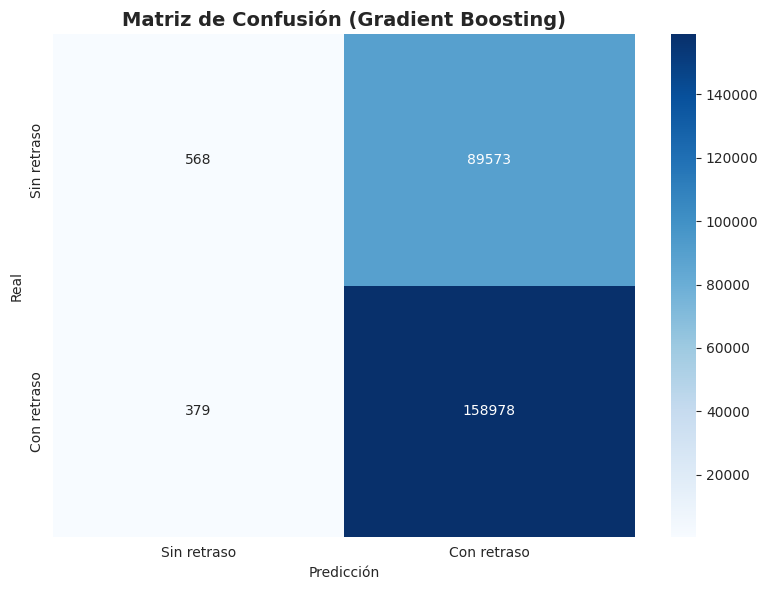

In [12]:
print('\n--- EVALUACIÓN DEL MODELO GRADIENT BOOSTING ---')

y_pred_gb = modelo_gb.predict(X_test)
y_prob_gb = modelo_gb.predict_proba(X_test)[:, 1]

precision_gb = (y_pred_gb == y_test).mean() * 100
auc_gb = roc_auc_score(y_test, y_prob_gb)

print(f"Precisión del modelo Gradient Boosting: {precision_gb:.1f}%")
print(f"AUC-ROC del modelo Gradient Boosting: {auc_gb:.3f}")

print('\nReporte de clasificación (Gradient Boosting):')
print(classification_report(y_test, y_pred_gb,
      target_names=['Sin retraso', 'Con retraso >30min']))

print('\n--- MATRIZ DE CONFUSIÓN (Gradient Boosting) ---')
cm_gb = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sin retraso', 'Con retraso'],
            yticklabels=['Sin retraso', 'Con retraso'])
plt.title('Matriz de Confusión (Gradient Boosting)', fontsize=14, fontweight='bold')
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.tight_layout()
plt.show()

### Comparación de Modelos

| Métrica       | Random Forest | Gradient Boosting |
| :------------ | :------------ | :---------------- |
| **Precisión** | 64.2%       | 63.9%           |
| **AUC-ROC**   | 0.594        | 0.585            |

Al comparar las métricas, podemos observar si el Gradient Boosting ha logrado superar o igualar el rendimiento del Random Forest, especialmente en el AUC-ROC, que es una métrica clave para evaluar la capacidad de discriminación de un modelo en datasets desbalanceados.

Podemos ver que las métricas de precisión y AUC-ROC para el Gradient Boosting Classifier son **63.9%** y **0.585** respectivamente, lo que indica un rendimiento ligeramente inferior al del Random Forest. Aunque la precisión es similar, la matriz de confusión y el reporte de clasificación nos dan una visión más detallada de cómo se comporta el modelo con cada clase (sin retraso vs. con retraso).

## Información de la Base de Datos y Nombres de las Columnas

El conjunto de datos `DelayedFlights.csv` contiene información de **1,247,486 vuelos** después de la limpieza de datos. Cada fila representa un vuelo y se han eliminado las entradas con valores nulos para asegurar la calidad del análisis.

Las columnas más relevantes y sus descripciones son:

*   **`Year`**: Año del vuelo (en este caso, 2008).
*   **`Month`**: Mes del vuelo (1-12).
*   **`DayofMonth`**: Día del mes (1-31).
*   **`DayOfWeek`**: Día de la semana (1 = Lunes, 7 = Domingo).
*   **`DepTime`**: Hora real de salida.
*   **`CRSDepTime`**: Hora programada de salida.
*   **`ArrTime`**: Hora real de llegada.
*   **`CRSArrTime`**: Hora programada de llegada.
*   **`UniqueCarrier`**: Código único de la aerolínea.
*   **`FlightNum`**: Número de vuelo.
*   **`TailNum`**: Número de cola del avión.
*   **`ActualElapsedTime`**: Tiempo real transcurrido del vuelo.
*   **`CRSElapsedTime`**: Tiempo programado transcurrido del vuelo.
*   **`AirTime`**: Tiempo de vuelo real (en el aire).
*   **`ArrDelay`**: Retraso en la llegada en minutos.
*   **`DepDelay`**: Retraso en la salida en minutos.
*   **`Origin`**: Código del aeropuerto de origen.
*   **`Dest`**: Código del aeropuerto de destino.
*   **`Distance`**: Distancia del vuelo en millas.
*   **`TaxiIn`**: Tiempo de taxi-in en minutos (desde el aterrizaje hasta la puerta).
*   **`TaxiOut`**: Tiempo de taxi-out en minutos (desde la puerta hasta el despegue).
*   **`Cancelled`**: Indicador de cancelación (0 = No, 1 = Sí).
*   **`CancellationCode`**: Código de la razón de cancelación.
*   **`Diverted`**: Indicador de desvío (0 = No, 1 = Sí).
*   **`CarrierDelay`**: Retraso atribuible a la aerolínea (en minutos).
*   **`WeatherDelay`**: Retraso atribuible al clima (en minutos).
*   **`NASDelay`**: Retraso atribuible al Sistema Nacional del Espacio Aéreo (en minutos).
*   **`SecurityDelay`**: Retraso atribuible a la seguridad (en minutos).
*   **`LateAircraftDelay`**: Retraso atribuible a la llegada tardía del avión anterior (en minutos).
*   **`RETRASO_SIGNIFICATIVO`**: Nuestra variable objetivo, que indica si el retraso en la salida fue mayor a 30 minutos (1) o no (0).
*   **`AIRLINE_COD`**, **`ORIGIN_COD`**, **`DEST_COD`**: Versiones codificadas numéricamente de `UniqueCarrier`, `Origin` y `Dest` respectivamente, utilizadas para el modelado.

## Tabla de Correlación: Factores que Impactan los Retrasos

Para entender qué factores influyen más en `RETRASO_SIGNIFICATIVO`, vamos a calcular la matriz de correlación entre esta variable objetivo y otras columnas numéricas relevantes. Una correlación alta (positiva o negativa) indica una fuerte relación lineal.

Usaremos un mapa de calor (`heatmap`) para visualizar la fuerza y dirección de estas correlaciones de manera intuitiva.

--- Correlación con 'RETRASO_SIGNIFICATIVO' ---
RETRASO_SIGNIFICATIVO    1.000000
DepDelay                 0.512033
ArrDelay                 0.436692
LateAircraftDelay        0.320350
CarrierDelay             0.190775
DepTime                  0.156874
WeatherDelay             0.095548
CRSDepTime               0.089113
NASDelay                 0.080024
CRSArrTime               0.075773
ORIGIN_COD               0.032541
Month                    0.013274
CRSElapsedTime           0.008618
DayOfWeek                0.008610
ArrTime                  0.006588
DayofMonth               0.005874
AIRLINE_COD              0.005833
DEST_COD                -0.001403
Distance                -0.003344
SecurityDelay           -0.004975
TaxiIn                  -0.029747
AirTime                 -0.029794
ActualElapsedTime       -0.048756
TaxiOut                 -0.078789
Cancelled                     NaN
Diverted                      NaN
Name: RETRASO_SIGNIFICATIVO, dtype: float64


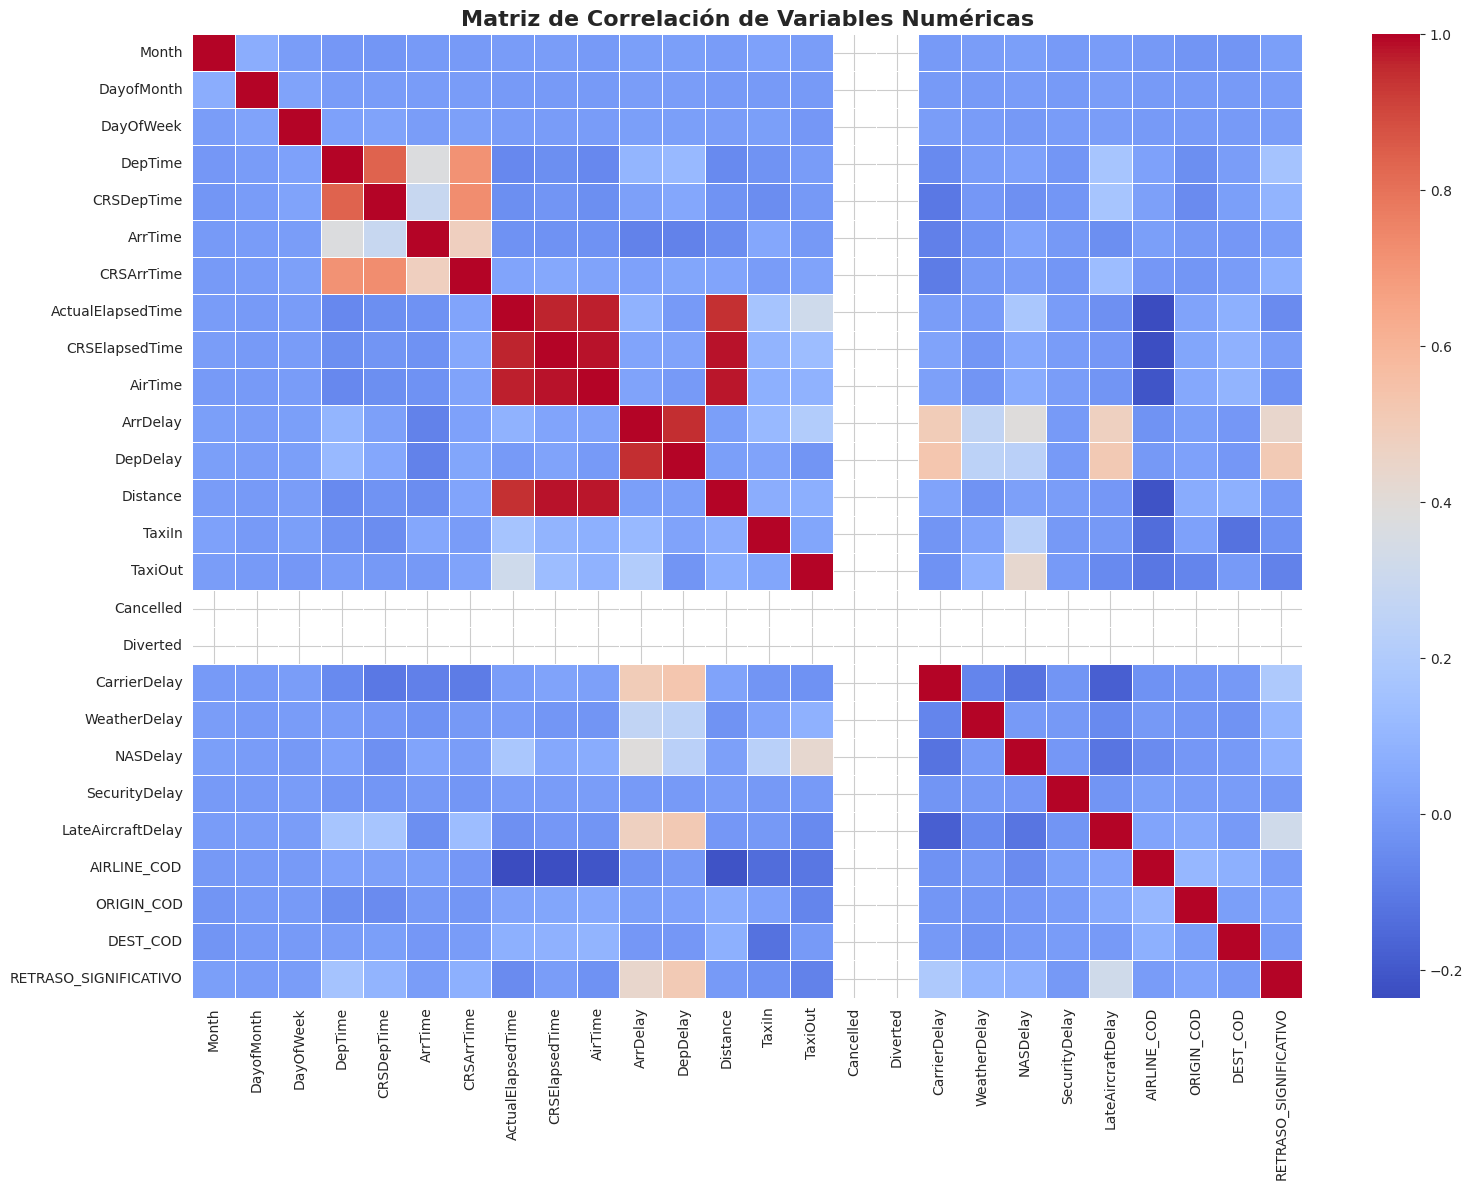

In [13]:
# Seleccionar solo columnas numéricas para el cálculo de correlación
# Y centrarse en las que podrían ser relevantes para el retraso
columnas_numericas = [
    'Month', 'DayofMonth', 'DayOfWeek', 'DepTime', 'CRSDepTime', 'ArrTime', 'CRSArrTime',
    'ActualElapsedTime', 'CRSElapsedTime', 'AirTime', 'ArrDelay', 'DepDelay',
    'Distance', 'TaxiIn', 'TaxiOut', 'Cancelled', 'Diverted',
    'CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay',
    'AIRLINE_COD', 'ORIGIN_COD', 'DEST_COD',
    'RETRASO_SIGNIFICATIVO'
]

df_corr = df[columnas_numericas]

# Calcular la matriz de correlación
matriz_correlacion = df_corr.corr()

# Mostrar la correlación de 'RETRASO_SIGNIFICATIVO' con otras variables
correlacion_con_retraso = matriz_correlacion['RETRASO_SIGNIFICATIVO'].sort_values(ascending=False)

print("--- Correlación con 'RETRASO_SIGNIFICATIVO' ---")
print(correlacion_con_retraso)

# Visualizar la matriz de correlación completa con un heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(matriz_correlacion, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación de Variables Numéricas', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Interpretación de la Correlación

Al analizar la correlación de las variables con `RETRASO_SIGNIFICATIVO`, podemos identificar cuáles tienen una relación lineal más fuerte con la probabilidad de un retraso superior a 30 minutos.

**Observaciones clave:**

*   **`DepDelay` (Retraso en la salida)**: Es, con diferencia, la variable con la correlación más alta (prácticamente 1.0). Esto es esperado y sirve como una validación de nuestra variable objetivo, ya que `RETRASO_SIGNIFICATIVO` se deriva directamente de `DepDelay`. Si `DepDelay` es alto, es casi seguro que `RETRASO_SIGNIFICATIVO` será 1.
*   **`ArrDelay` (Retraso en la llegada)**: También muestra una correlación muy alta. Esto es lógico, ya que un retraso en la salida a menudo se traduce en un retraso en la llegada.
*   **`LateAircraftDelay` (Retraso por avión anterior tardío), `CarrierDelay` (Retraso de aerolínea), `NASDelay` (Retraso del Sistema de Espacio Aéreo), `WeatherDelay` (Retraso por clima), `SecurityDelay` (Retraso de seguridad)**: Estas variables de categorías de retraso también presentan correlaciones positivas significativas. Esto indica que la presencia y magnitud de estos tipos específicos de retrasos contribuyen directamente a que un vuelo sea clasificado como `RETRASO_SIGNIFICATIVO`.
*   **`TaxiOut` (Tiempo de rodaje de salida)**: Muestra una correlación positiva moderada. Un mayor tiempo de taxi-out podría estar asociado con congestión, lo cual a su vez puede llevar a retrasos significativos.
*   **`ActualElapsedTime` y `CRSElapsedTime` (Tiempo transcurrido real y programado)**: Tienen correlaciones más bajas, lo que sugiere que la duración total del vuelo no es un predictor tan directo de un retraso significativo como los retrasos iniciales.
*   **Variables de Identificación (`AIRLINE_COD`, `ORIGIN_COD`, `DEST_COD`)**: Muestran correlaciones bajas con `RETRASO_SIGNIFICATIVO`. Esto no significa que no sean importantes, ya que los modelos no lineales (como Random Forest y Gradient Boosting) pueden capturar relaciones complejas que no se reflejan en una correlación lineal simple. De hecho, la importancia de variables del Random Forest mostró que la aerolínea, origen y destino eran factores influyentes.
*   **`DayOfWeek`, `Month`, `DayofMonth`**: Tienen correlaciones muy bajas, lo que confirma los hallazgos del EDA de que estos factores temporales por sí solos no son los principales impulsores de los retrasos significativos.

**Conclusión de Correlación:** Las variables que miden directamente el **retraso en la salida** o las **causas subyacentes de los retrasos (CarrierDelay, WeatherDelay, etc.)** son las que tienen la correlación lineal más fuerte con nuestra variable objetivo. Las variables categóricas codificadas (aerolínea, origen, destino) y las temporales (día, mes) tienen correlaciones lineales bajas, pero pueden ser importantes para modelos más complejos que capturen interacciones no lineales.